# PROJECT: Predict Student Health Risk Using Machine Learning
## Complete by : Phan Chung
## Date : 2026-07-28

## Task 1: Import the necessary libraries and read the dataset 

In [119]:
# import common libraries
import pandas as pd
import numpy as np
import sklearn
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib as mpl
import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [120]:
# read the dataset
from pathlib import Path

def find_data_file(filename):
    for directory in [Path.cwd(), *Path.cwd().parents]:
        candidate = directory / filename
        if candidate.exists():
            return candidate
        matches = list(directory.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Could not find {filename} in the current or parent directories.")

train_path = find_data_file('train.csv')
test_path = find_data_file('test.csv')

student_train = pd.read_csv(train_path)
student_test = pd.read_csv(test_path)

In [121]:
student_train.head() 


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [122]:
student_test.head()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


### Task 2: Data EDA 

#### 1. Explore the dataset 

In [123]:
# check the shape of train set and test set
print(f" Shape of train set: {student_train.shape}")
print(f" Shape of test set: {student_test.shape}")

 Shape of train set: (690088, 15)
 Shape of test set: (295753, 14)


In [124]:
student_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [125]:
student_train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [126]:
train_data= student_train.copy()
train_data.drop(['id'], axis=1, inplace=True)
train_data.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


array([[<Axes: title={'center': 'sleep_duration'}>,
        <Axes: title={'center': 'heart_rate'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'calorie_expenditure'}>,
        <Axes: title={'center': 'step_count'}>,
        <Axes: title={'center': 'exercise_duration'}>],
       [<Axes: title={'center': 'water_intake'}>, <Axes: >, <Axes: >]],
      dtype=object)

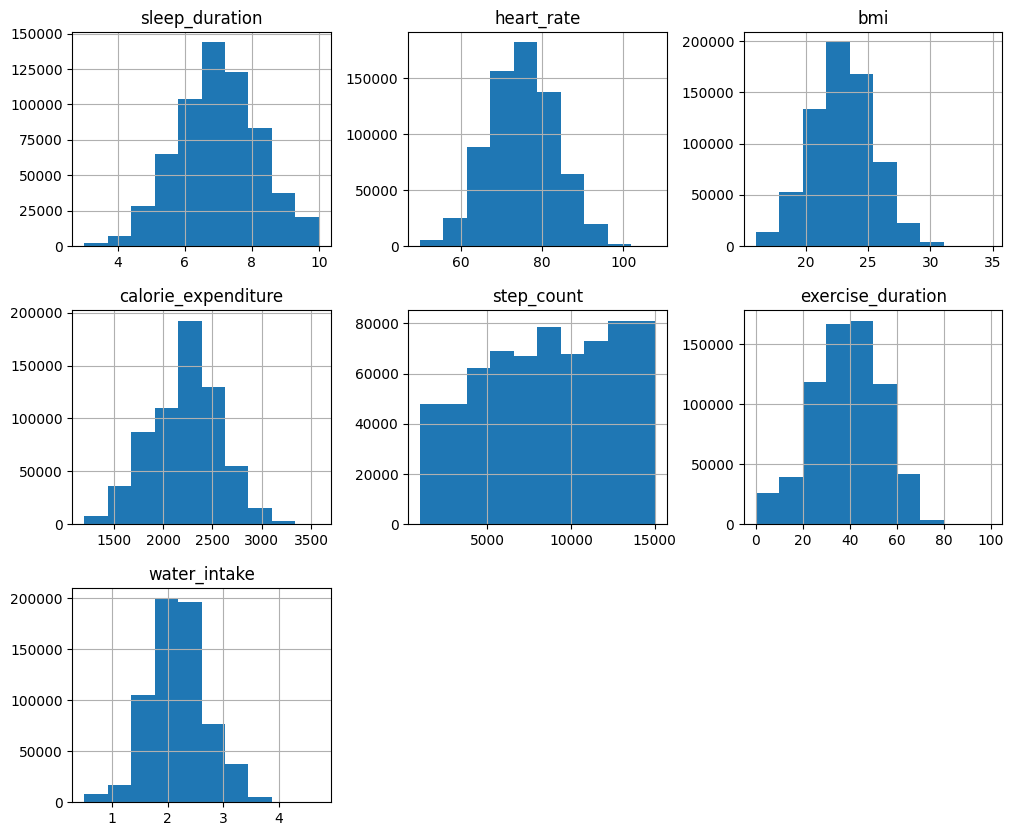

In [127]:
train_data.hist(figsize=(12, 10))

In [128]:
train_data['health_condition'].value_counts()

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

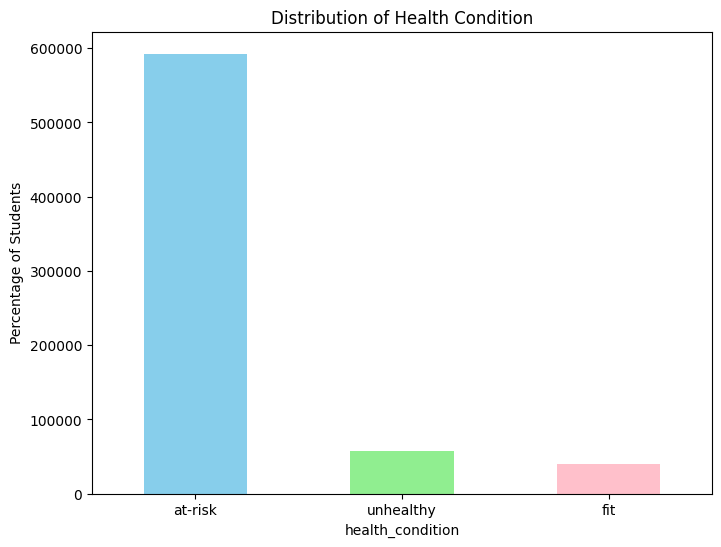

In [129]:
train_data['health_condition'].value_counts().plot(kind='bar', 
                figsize=(8, 6),
                rot=0,
                color=['skyblue','lightgreen','pink'])
plt.title('Distribution of Health Condition')
plt.ylabel('Percentage of Students')
plt.show()

#### The bar chart show the distribution of target variable 'health_risk' is unbalance classification problem. The majority of students are in 'at-risk' category, minority of them are in unhealthy condition and only a few of them are in healthy condition. Therefore, we need to apply some techniques to handle the unbalanced classification problem. 

In [130]:
# correlation between numerical features with the target variable
health_condition_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}

train_data['health_condition_mapped'] = train_data['health_condition'].map(health_condition_mapping)

corr_matrix = train_data.select_dtypes(include=[np.number]).corr(method='spearman')
# correlation with the target variable
corr_matrix['health_condition_mapped'].sort_values(ascending=False)

health_condition_mapped    1.000000
exercise_duration          0.145368
step_count                 0.143934
calorie_expenditure        0.076720
bmi                        0.016061
heart_rate                -0.003845
water_intake              -0.005515
sleep_duration            -0.146031
Name: health_condition_mapped, dtype: float64

In [131]:
train_data['health_condition_mapped'].value_counts()

health_condition_mapped
0    592561
1     57724
2     39803
Name: count, dtype: int64

#### 2. Check for missing values in the dataset and handle them appropriately.

In [132]:
# check any missing values in the dataset
train_data.isna().sum()

health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
health_condition_mapped        0
dtype: int64

#### It shows that there are many missing values in both numerical and categorical columns. We can handle the missing value by using pipeline transformation to fill the missing value with median for numerical columns and KNN imputer for categorical columns.

In [133]:
# drop the health_condition_mapped column as it was only used for correlation analysis
#train_data.drop(columns=['health_condition_mapped'], inplace=True, errors='ignore')
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   health_condition         690088 non-null  object 
 1   sleep_duration           614089 non-null  float64
 2   heart_rate               682255 non-null  float64
 3   bmi                      676190 non-null  float64
 4   calorie_expenditure      637235 non-null  float64
 5   step_count               676172 non-null  float64
 6   exercise_duration        683187 non-null  float64
 7   water_intake             646611 non-null  float64
 8   diet_type                683187 non-null  object 
 9   stress_level             607277 non-null  object 
 10  sleep_quality            631757 non-null  object 
 11  physical_activity_level  653467 non-null  object 
 12  smoking_alcohol          661506 non-null  object 
 13  gender                   668715 non-null  object 
 14  heal

## Task 3: Data Preprocessing and Cleaning

### 1. Separate the features and target variable from the dataset

In [134]:
# separate target variable in train set
# drop both the original and mapped target columns from features
X_train = train_data.drop(['health_condition', 'health_condition_mapped'], axis=1)
y_train = train_data['health_condition_mapped']

# separate target variable in test set
X_test= student_test.drop(['id'], axis=1)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   sleep_duration           263182 non-null  float64
 1   heart_rate               292396 non-null  float64
 2   bmi                      289797 non-null  float64
 3   calorie_expenditure      273101 non-null  float64
 4   step_count               289789 non-null  float64
 5   exercise_duration        292795 non-null  float64
 6   water_intake             277120 non-null  float64
 7   diet_type                292795 non-null  object 
 8   stress_level             260263 non-null  object 
 9   sleep_quality            270754 non-null  object 
 10  physical_activity_level  280058 non-null  object 
 11  smoking_alcohol          283504 non-null  object 
 12  gender                   286593 non-null  object 
dtypes: float64(7), object(6)
memory usage: 29.3+ MB


### 2. Handle the missing values in the dataset using pipeline transformation

### 1. Train set

In [135]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=[object]).columns.tolist()

cat_pipeline= make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore')
)

num_pipeline= make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, cat_features)
])

transformed_X_train= preprocessing.fit_transform(X_train)


In [136]:
transformed_X_train.shape
#transformed_X_train

(690088, 25)

In [137]:
transformed_X_train.dtype
type(transformed_X_train)

numpy.ndarray

In [138]:
# get feature names after transformation
transformed_feature_names = preprocessing.get_feature_names_out()

train_df = pd.DataFrame(transformed_X_train, columns=transformed_feature_names)

train_df.head()

,num__sleep_duration,num__heart_rate,num__bmi,num__calorie_expenditure,num__step_count,num__exercise_duration,num__water_intake,cat__diet_type_balanced,cat__diet_type_non-veg,cat__diet_type_veg,...,cat__sleep_quality_poor,cat__physical_activity_level_active,cat__physical_activity_level_moderate,cat__physical_activity_level_sedentary,cat__smoking_alcohol_no,cat__smoking_alcohol_occasional,cat__smoking_alcohol_yes,cat__gender_female,cat__gender_male,cat__gender_other
0,-1.546057,-0.553173,1.088904,-0.155962,-1.874228,-1.292002,-0.654609,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,-1.275675,-0.467057,1.162174,-0.778795,0.327811,0.760044,-1.850089,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-1.485003,0.037337,0.633002,1.383152,1.439758,-0.044413,-1.172651,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-1.999600,0.258778,0.059054,1.209478,-0.370722,1.441787,-0.335815,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.207062,-0.208709,2.220519,0.999871,-0.522410,0.494165,0.122453,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [139]:
type(train_df)

pandas.core.frame.DataFrame

#### 2. Test set

In [140]:
transformed_X_test= preprocessing.transform(X_test)


#### 3. Model training train set

In [141]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error as MSE

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_rf,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search_rf.fit(transformed_X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(transformed_X_test)
print(f"Best Random Forest Model: {best_rf_model}")
print(f"Random Forest Predictions: {y_pred_rf}")
print("Best Random Forest Model Parameters:", grid_search_rf.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest Model: RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)
Random Forest Predictions: [1 0 0 ... 0 0 1]
Best Random Forest Model Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [142]:
#from sklearn.model_selection import cross_validate
# use weighted precision/recall and multiclass-capable ROC AUC
#scoring_metric = ['accuracy', 'precision_weighted', 'recall_weighted', 'roc_auc_ovr']
#cv_results = cross_validate(best_rf_model, transformed_X_train, y_train, cv=3, scoring=scoring_metric, return_train_score=True, n_jobs=-1)

#for metric in scoring_metric:
   # print(f"Mean {metric} score: {cv_results['test_' + metric].mean():.3f}")

# PART 2. Test set

In [143]:
num_test= X_test.select_dtypes(include=[np.number]).columns.tolist()
cat_test= X_test.select_dtypes(include=[object]).columns.tolist()

